# 04 Figures

We build every figure from the files that `01_dasymetric_population`, `02_network_accessibility`, and `03_substitution_analysis` export, and we compute no new results. Captions live in the manuscript, so the figures carry a title and panel letters only.

## Figures

| # | Save name | Content |
|---|---|---|
| 1 | `fig1_supply` | Supply by area against supply by count |
| 2 | `fig2_competition` | Standard against competition-weighted 2SFCA |
| 3 | `fig3_mechanism` | Loss and offset at two block groups |
| 4 | `fig4_design_waves` | Closure window, announcement waves, offset added by wave |
| 5 | `fig5_loss_offset` | Where loss and offset landed |
| 6 | `fig6_exposure` | Population waffle, who lost access and who was reached |
| 7 | `fig7_equity_gradient` | Loss and offset by population-weighted quintile |
| 8 | `fig8_forest` | Standardized coefficients on offset level |
| 9 | `fig9_sensitivity` | Borough and citywide offset across specifications |

## Palette

Borough hues follow Okabe-Ito families with lightness re-spaced so the five boroughs stay separable in grayscale, where the smallest gap in relative luminance between boroughs is 0.06. Boroughs also carry a marker shape in `BORO_MK`, and the sensitivity figure draws each borough as its own outline, so color never serves as the only channel.

| Role | Hex | Gray |
|---|---|---|
| Bronx | `#535D66` | 0.11 |
| Brooklyn | `#333C46` | 0.04 |
| Manhattan | `#728187` | 0.21 |
| Queens | `#B3A08A` | 0.37 |
| Staten Island | `#DBC39F` | 0.57 |
| Loss | `#803733` | 0.08 |
| Open Streets | `#487BA7` | 0.18 |
| Offset | `#7FA186` | 0.32 |
| Park | `#9BB385` | 0.38 |
| De-emphasis | `#C9C9C9` | 0.58 |

In [2]:
import json
import sys
import textwrap
import warnings

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patheffects as pe
from matplotlib import font_manager
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.path import Path
from matplotlib.patches import Rectangle, Circle, FancyArrowPatch, Patch
from shapely import wkt as _wkt
from shapely.affinity import affine_transform
from shapely.geometry import Polygon, MultiPolygon

sys.path.append("../src")
from paths import RAW, PROCESSED, CRS_PROJECTED

FIGS = PROCESSED.parent.parent / "figures"
FIGS.mkdir(exist_ok=True, parents=True)

INK, LOSS, GAIN, OSC = "#1A1A1A", "#803733", "#7FA186", "#487BA7"
PARKC, FADE, STREET, PALE = "#9BB385", "#C9C9C9", "#E4E4E4", "#EDEDED"
BORO = ["Bronx", "Brooklyn", "Manhattan", "Queens", "Staten Island"]


def lum(hx):
    c = np.array([int(hx[i:i + 2], 16) / 255 for i in (1, 3, 5)])
    lin = np.where(c <= 0.04045, c / 12.92, ((c + 0.055) / 1.055) ** 2.4)
    return float(lin @ [0.2126, 0.7152, 0.0722])


# borough colors spaced by lightness so they separate in grayscale
BORO_C = dict(zip(BORO, ["#535D66", "#333C46", "#728187", "#B3A08A", "#DBC39F"]))
BORO_MK = dict(zip(BORO, ["o", "s", "D", "^", "v"]))
BORO_TXT = {b: ("white" if lum(c) < 0.179 else "#141414") for b, c in BORO_C.items()}

OSC_CMAP = LinearSegmentedColormap.from_list(
    "osc", ["#F2F5F7", "#C3D0DC", "#8CA3BC", "#5A7B9E", "#33547A"])
LOSS_CMAP = LinearSegmentedColormap.from_list(
    "loss", ["#F7F3F2", "#DEC5C1", "#C08D87", "#9C5A52", "#6E2B26"])

MM = 1 / 25.4
W2, W1 = 183 * MM, 89 * MM

# first installed font; a list makes matplotlib warn for each missing family
installed = {f.name for f in font_manager.fontManager.ttflist}
FONT = next((f for f in ["Gill Sans MT", "Gill Sans"] if f in installed), "DejaVu Sans")

mpl.rcParams.update({
    "font.family": FONT, "font.size": 8.5,
    "axes.linewidth": 0.6, "axes.edgecolor": "#777777", "axes.titlesize": 9.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.axisbelow": True, "grid.color": "#ECECEC", "grid.linewidth": 0.5,
    "xtick.color": "#777777", "ytick.color": "#777777",
    "xtick.labelsize": 8, "ytick.labelsize": 8,
    "text.color": INK, "axes.labelcolor": INK, "axes.labelsize": 8.5,
    "figure.dpi": 130, "savefig.dpi": 300,
    "savefig.bbox": "tight", "savefig.pad_inches": 0.18,
    "pdf.fonttype": 42, "ps.fonttype": 42,
    "mathtext.fontset": "dejavusans",
})


def save(fig, name):
    fig.savefig(FIGS / f"{name}.pdf")
    fig.savefig(FIGS / f"{name}.png")


print(f"font: {FONT}")

font: Gill Sans MT


In [3]:
bg = pd.read_csv(PROCESSED / "equity_blockgroup.csv", dtype={"bg_geoid": str})
grads = pd.read_csv(PROCESSED / "equity_gradients.csv")
sens = pd.read_csv(PROCESSED / "sensitivity.csv")
meta = json.load(open(PROCESSED / "2sfca_meta.json"))
emeta = json.load(open(PROCESSED / "equity_meta.json"))

WKEY = [d[5:].replace("-", "") for d in meta["waves"]]

corr = pd.read_csv(PROCESSED / "corridors.csv", parse_dates=["open_dt"])
corr_g = gpd.GeoDataFrame(corr, geometry=corr["wkt"].map(_wkt.loads), crs=CRS_PROJECTED)
pk = pd.read_csv(PROCESSED / "parks.csv")
parks_g = gpd.GeoDataFrame(pk, geometry=pk["wkt"].map(_wkt.loads), crs=CRS_PROJECTED)
pgd = pd.read_csv(PROCESSED / "playgrounds.csv")
pg_g = gpd.GeoDataFrame(pgd, geometry=gpd.points_from_xy(pgd["x"], pgd["y"]), crs=CRS_PROJECTED)

cat = pd.read_csv(PROCESSED / "example_catchments.csv", dtype={"bg_geoid": str})
sup_ex = pd.read_csv(PROCESSED / "example_supply.csv", dtype={"bg_geoid": str, "sid": str})

IDS = ["360610050004", "360810528001"]

print(f"{len(bg):,} block groups  |  {corr_g['corr_id'].nunique()} corridors "
      f"({len(corr_g)} supply points), {len(parks_g):,} parks, {len(pg_g):,} playgrounds")

6,380 block groups  |  184 corridors (191 supply points), 2,049 parks, 1,030 playgrounds


In [4]:
blocks = gpd.read_file(RAW / "tl_2020_36_tabblock20.zip")
blocks = blocks[blocks["COUNTYFP20"].isin(["005", "047", "061", "081", "085"])].to_crs(CRS_PROJECTED)
blocks["bg_geoid"] = blocks["GEOID20"].astype(str).str.zfill(15).str[:12]

bg_geo = blocks.dissolve(by="bg_geoid")[["geometry"]].reset_index().merge(bg, on="bg_geoid", how="inner")
bg_geo = gpd.GeoDataFrame(bg_geo, geometry="geometry", crs=CRS_PROJECTED)

print(f"{len(bg_geo):,} of {len(bg):,} block groups with geometry")

6,380 of 6,380 block groups with geometry


In [5]:
w = bg["pop"]
wb, wc, wo = (np.average(bg[c], weights=w) for c in ["baseline", "closure", f"os_{WKEY[-1]}"])
CITY_LOSS = 100 * (wb - wc) / wb
CITY_OFF = 100 * (wo - wc) / (wb - wc)

print(f"citywide loss {CITY_LOSS:.2f}%   offset {CITY_OFF:.2f}% of loss")

citywide loss 26.84%   offset 10.19% of loss


In [6]:
BORO_FP = {"005": "Bronx", "047": "Brooklyn", "061": "Manhattan",
           "081": "Queens", "085": "Staten Island"}


def fill_holes(g):
    ps = list(g.geoms) if g.geom_type == "MultiPolygon" else [g]
    return MultiPolygon([Polygon(p.exterior) for p in ps])


land = blocks[blocks["ALAND20"] > 0].assign(Borough=blocks["COUNTYFP20"].map(BORO_FP))
nyc = land.dissolve(by="Borough")[["geometry"]]
nyc["geometry"] = nyc.geometry.buffer(150).buffer(-150).map(fill_holes)

print(f"{len(land):,} land blocks of {len(blocks):,}")
print(nyc.index.tolist())

37,380 land blocks of 37,984
['Bronx', 'Brooklyn', 'Manhattan', 'Queens', 'Staten Island']


## Figure 1. Supply composition

{'park': 98.77, 'playground': 4.12, 'openstreet': 0.44} {'park': 2049, 'playground': 1030, 'openstreet': 191}


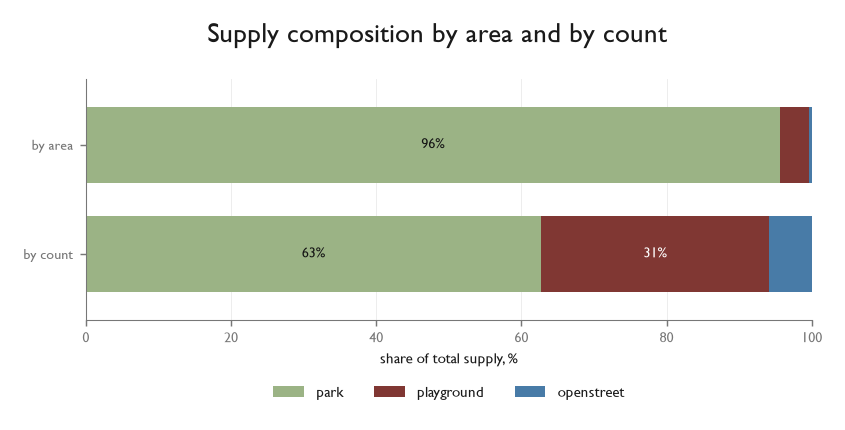

In [8]:
opp = meta["supply_points"]
cap = meta["capacity_km2"]
kinds = ["park", "playground", "openstreet"]

share_cap = np.array([cap[k] for k in kinds]) / sum(cap.values()) * 100
share_opp = np.array([opp[k] for k in kinds]) / sum(opp.values()) * 100

fig, ax = plt.subplots(figsize=(W2, 2.4))
y = np.arange(2)
left = np.zeros(2)
for k, sc, so, c in zip(kinds, share_cap, share_opp, [PARKC, LOSS, OSC]):
    vals = np.array([sc, so])
    ax.barh(y, vals, left=left, color=c, label=k, height=0.7)
    for yi, (v, l) in enumerate(zip(vals, left)):
        if v > 6:
            ax.text(l + v / 2, yi, f"{v:.0f}%", ha="center", va="center",
                    color="white" if c in (LOSS, OSC) else "#141414", fontsize=8)
    left += vals

ax.set_yticks(y, ["by area", "by count"])
ax.set_ylim(1.6, -0.6)
ax.set_xlim(0, 100)
ax.set_xlabel("share of total supply, %")
ax.grid(axis="x")
ax.legend(ncol=3, frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.22))

fig.suptitle("Supply composition by area and by count", y=1.06, fontsize=15)

print({k: round(cap[k], 2) for k in kinds}, opp)

save(fig, "fig1_supply")

## Figure 2. Standard and competition-weighted 2SFCA

In [10]:
CEN = bg_geo.loc[bg_geo["bg_geoid"] == IDS[0], "geometry"].centroid.iloc[0]
HALF_FT = 730 / 2 * 3.280839895
win = (CEN.x - HALF_FT, CEN.y - HALF_FT, CEN.x + HALF_FT, CEN.y + HALF_FT)

bak = gpd.read_file(RAW / "lion" / "lion.gdb", layer="lion",
                    columns=["SegmentID"], bbox=win)
bak = bak[bak.geometry.notna()].to_crs(CRS_PROJECTED)

sc = 1 / (2 * HALF_FT)
bak_u = bak.copy()
bak_u["geometry"] = bak_u.geometry.apply(
    lambda g: affine_transform(g, [sc, 0, 0, sc, -win[0] * sc, -win[1] * sc]))
bak_u = gpd.clip(bak_u, Polygon([(0, 0), (1, 0), (1, 1), (0, 1)])).reset_index(drop=True)

SITES = {
    "park A":  dict(xy=(0.15, 0.83), kind="park", r=0.110, cap=8.0),
    "park B":  dict(xy=(0.89, 0.64), kind="park", r=0.058, cap=1.6),
    "playgr.": dict(xy=(0.53, 0.92), kind="play", r=0.062, cap=1.2),
    "Open St": dict(xy=(0.74, 0.17), kind="os",   r=0.0,   cap=0.5),
}
PPL = [(0.30, 0.46), (0.48, 0.32), (0.62, 0.58)]
LIVE = ["park A", "park B", "Open St"]

target = np.array(SITES["Open St"]["xy"])
mids = bak_u.geometry.interpolate(0.5, normalized=True)
seg = bak_u.loc[np.hypot(mids.x - target[0], mids.y - target[1]).idxmin(), "geometry"]
part = seg.geoms[0] if seg.geom_type == "MultiLineString" else seg
c = np.array(part.coords)
v = (c[-1] - c[0]) / np.linalg.norm(c[-1] - c[0])
mid = (c[0] + c[-1]) / 2
OS_LINE = (mid - v * 0.11, mid + v * 0.11)
SITES["Open St"]["xy"] = tuple(mid)

print(f"{len(bak_u)} segments, corridor from {OS_LINE[0].round(3)} to {OS_LINE[1].round(3)}")

270 segments, corridor from [0.606 0.198] to [0.798 0.091]


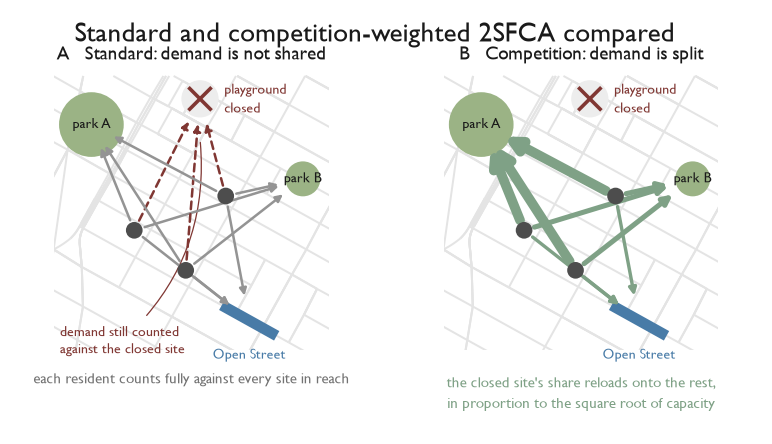

In [11]:
def scene(ax, title, mode):
    bak_u.plot(ax=ax, color=STREET, lw=1.1, zorder=0)
    for name, s in SITES.items():
        x, y = s["xy"]
        if s["kind"] == "os":
            (x0, y0), (x1, y1) = OS_LINE
            ax.plot([x0, x1], [y0, y1], color=OSC, lw=6, solid_capstyle="butt", zorder=2)
            ax.text((x0 + x1) / 2, min(y0, y1) - 0.045, "Open Street",
                    ha="center", va="top", fontsize=7.5, color=OSC)
        elif s["kind"] == "park":
            ax.add_patch(Circle((x, y), s["r"], color=PARKC, zorder=2))
            ax.text(x, y, name, ha="center", va="center", fontsize=7.5, zorder=3)
        else:
            ax.add_patch(Circle((x, y), s["r"], color=PALE, zorder=2))
            for sgn in (1, -1):
                ax.plot([x - 0.036, x + 0.036], [y - 0.036 * sgn, y + 0.036 * sgn],
                        color=LOSS, lw=2.0, zorder=3)
            ax.text(x + 0.085, y, "playground\nclosed", ha="left", va="center",
                    fontsize=8, color=LOSS, linespacing=1.3)
    for p in PPL:
        ax.add_patch(Circle(p, 0.026, color="0.30", zorder=5))

    tot = sum(np.sqrt(SITES[n]["cap"]) for n in LIVE)
    for p in PPL:
        if mode == "standard":
            for nm in LIVE:
                ax.add_patch(FancyArrowPatch(p, SITES[nm]["xy"], arrowstyle="-|>",
                                             mutation_scale=8, color="0.58", lw=1.4,
                                             shrinkA=6, shrinkB=14, zorder=4))
            ax.add_patch(FancyArrowPatch(p, SITES["playgr."]["xy"], arrowstyle="-|>",
                                         mutation_scale=8, color=LOSS, lw=1.4,
                                         ls=(0, (3, 2)), shrinkA=6, shrinkB=14, zorder=4))
        else:
            for nm in LIVE:
                wgt = np.sqrt(SITES[nm]["cap"]) / tot
                ax.add_patch(FancyArrowPatch(p, SITES[nm]["xy"], arrowstyle="-|>",
                                             mutation_scale=6 + 16 * wgt,
                                             color=GAIN, lw=0.7 + 8.0 * wgt,
                                             shrinkA=6, shrinkB=14, zorder=4))

    if mode == "standard":
        ax.annotate("demand still counted\nagainst the closed site",
                    (0.53, 0.78), (0.04, 0.14), fontsize=8, color=LOSS,
                    ha="left", va="top", linespacing=1.4,
                    arrowprops=dict(arrowstyle="-", color=LOSS, lw=0.7,
                                    connectionstyle="arc3,rad=0.25"))

    ax.set_title(title, loc="center", fontsize=10.5, pad=6)
    ax.set_xlim(0.02, 0.98); ax.set_ylim(0.04, 1.02)
    ax.set_aspect("equal"); ax.axis("off")


fig = plt.figure(figsize=(W2, 3.5))
gs = GridSpec(2, 2, height_ratios=[2.0, 0.36], hspace=0.12, wspace=0.16)

scene(fig.add_subplot(gs[0, 0]), "A   Standard: demand is not shared", "standard")
scene(fig.add_subplot(gs[0, 1]), "B   Competition: demand is split", "competition")

n0 = fig.add_subplot(gs[1, 0]); n0.axis("off"); n0.set_xlim(0, 1); n0.set_ylim(0, 1)
n0.text(0.5, 0.95, "each resident counts fully against every site in reach",
        ha="center", va="top", fontsize=8.5, color="0.45")

n1 = fig.add_subplot(gs[1, 1]); n1.axis("off"); n1.set_xlim(0, 1); n1.set_ylim(0, 1)
n1.text(0.5, 0.95, "the closed site's share reloads onto the rest,\n"
                   "in proportion to the square root of capacity",
        ha="center", va="top", fontsize=8.5, color=GAIN, linespacing=1.5)

fig.suptitle("Standard and competition-weighted 2SFCA compared",
             y=0.985, fontsize=15)

save(fig, "fig2_competition")

## Figure 3. Loss and offset at two block groups

360610050004  Manhattan:  8 parks, 2 playgrounds, 6 corridors
360810528001  Queens:  2 parks, 1 playgrounds, 0 corridors
window 2.22 km across


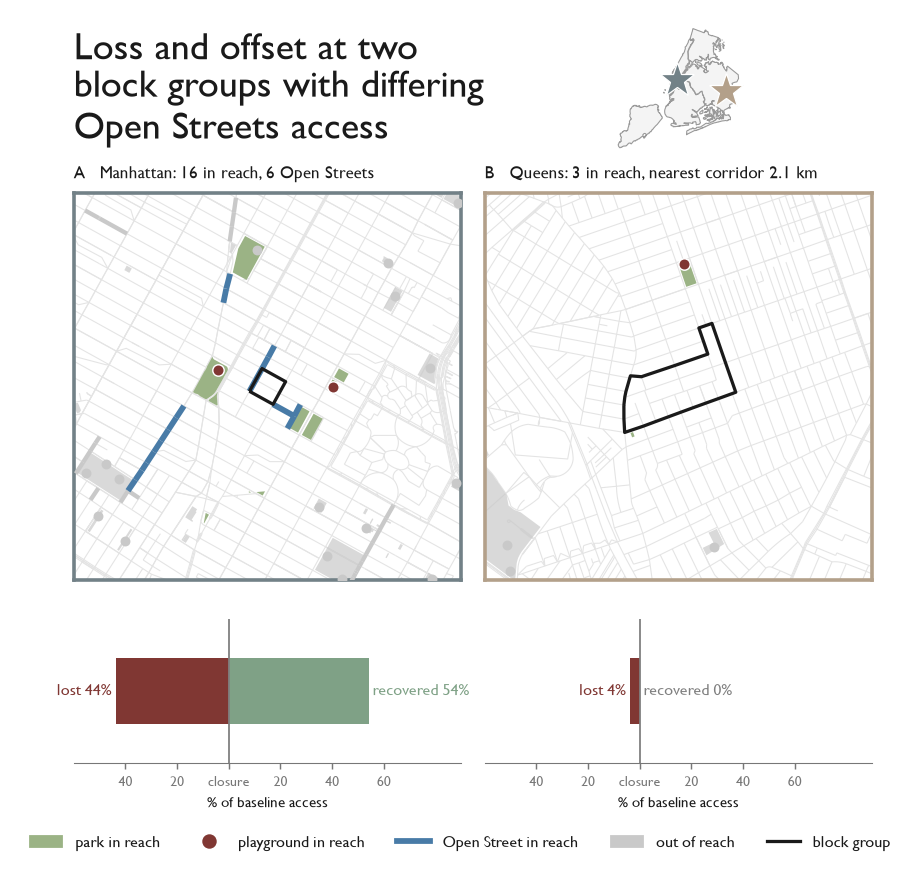

In [13]:
MARK = {IDS[0]: BORO_C["Manhattan"], IDS[1]: BORO_C["Queens"]}
BAR_LOSS, BAR_GAIN = LOSS, GAIN

KINDS = {}
TITLES = []
for bgid in IDS:
    s = sup_ex[sup_ex["bg_geoid"] == bgid]
    KINDS[bgid] = {k: set(s.loc[s["kind"] == k, "sid"].astype(str))
                   for k in ("park", "playground", "openstreet")}
    n = {k: len(v) for k, v in KINDS[bgid].items()}
    boro = bg.set_index("bg_geoid").loc[bgid, "Borough"]
    tot = sum(n.values())
    if n["openstreet"]:
        TITLES.append(f"{boro}: {tot} in reach, {n['openstreet']} Open Streets")
    else:
        geom = bg_geo.loc[bg_geo["bg_geoid"] == bgid, "geometry"].iloc[0]
        km = corr_g.distance(geom).min() / 3.280839895 / 1000
        TITLES.append(f"{boro}: {tot} in reach, nearest corridor {km:.1f} km")
    print(f"{bgid}  {boro}:  {n['park']} parks, {n['playground']} playgrounds, "
          f"{n['openstreet']} corridors")

spans = []
for i in IDS:
    cs = cat[cat["bg_geoid"] == i]
    cen = bg_geo.loc[bg_geo["bg_geoid"] == i, "geometry"].centroid.iloc[0]
    spans.append(max(abs(cs["x"] - cen.x).max(), abs(cs["y"] - cen.y).max()))

HALF = max(spans) * 1.06
WIN_KM = 2 * HALF / 3.280839895 / 1000
print(f"window {WIN_KM:.2f} km across")

fig = plt.figure(figsize=(W2 * 1.1, 7.4))
gs = GridSpec(3, 2, height_ratios=[1.0, 3.2, 1.1], hspace=0.10, wspace=0.06,
              width_ratios=[1, 1])

loc = fig.add_subplot(gs[0, 1])
nyc.plot(ax=loc, color="#F4F4F4", edgecolor="0.6", lw=0.6)
for i in IDS:
    cen = bg_geo.loc[bg_geo["bg_geoid"] == i, "geometry"].centroid.iloc[0]
    loc.plot(cen.x, cen.y, marker="*", color=MARK[i], ms=20, ls="",
             markeredgecolor="white", markeredgewidth=0.7, zorder=3)
loc.set_aspect("equal"); loc.axis("off")

for j, (bgid, title) in enumerate(zip(IDS, TITLES)):
    ax = fig.add_subplot(gs[1, j])
    cen = bg_geo.loc[bg_geo["bg_geoid"] == bgid, "geometry"].centroid.iloc[0]
    box = (cen.x - HALF, cen.y - HALF, cen.x + HALF, cen.y + HALF)
    kin = KINDS[bgid]

    st = gpd.read_file(RAW / "lion" / "lion.gdb", layer="lion",
                       columns=["SegmentID"], bbox=box)
    st.plot(ax=ax, color=STREET, lw=0.6, zorder=0)

    win = lambda g: g.cx[box[0]:box[2], box[1]:box[3]]
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        p = win(parks_g)
        hit = p["park_id"].astype(str).isin(kin["park"])
        p[~hit].plot(ax=ax, color=FADE, lw=0, alpha=0.7, zorder=1)
        p[hit].plot(ax=ax, color=PARKC, lw=0, zorder=2)
        co = win(corr_g)
        hit = co["os_id"].astype(str).isin(kin["openstreet"])
        co[~hit].plot(ax=ax, color=FADE, lw=2.4, zorder=3)
        co[hit].plot(ax=ax, color=OSC, lw=3.2, zorder=4)
        pw = win(pg_g)
        hit = pw["pg_id"].astype(str).isin(kin["playground"])
        pw[~hit].plot(ax=ax, color=FADE, markersize=20, zorder=3)
        pw[hit].plot(ax=ax, color=LOSS, markersize=40,
                     edgecolor="white", lw=0.8, zorder=5)

    bg_geo[bg_geo["bg_geoid"] == bgid].boundary.plot(ax=ax, color=INK, lw=1.8, zorder=6)
    ax.set_xlim(box[0], box[2]); ax.set_ylim(box[1], box[3])
    ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    for s in ax.spines.values():
        s.set_visible(True); s.set_color(MARK[bgid]); s.set_linewidth(2.0)
    ax.set_title(f"{'AB'[j]}   {title}", loc="left", fontsize=9.5, color=INK, pad=8)

    axb = fig.add_subplot(gs[2, j])
    r = bg.set_index("bg_geoid").loc[bgid]
    b, c, o = r["baseline"], r["closure"], r[f"os_{WKEY[-1]}"]
    lost, rec = 100 * (b - c) / b, 100 * (o - c) / b
    axb.axvline(0, color="0.5", lw=1)
    axb.barh(0, -lost, height=0.55, color=BAR_LOSS)
    axb.barh(0, rec, height=0.55, color=BAR_GAIN)
    axb.text(-lost - 1.5, 0, f"lost {lost:.0f}%", ha="right", va="center",
             fontsize=9, color=BAR_LOSS)
    axb.text(max(rec, 0) + 1.5, 0, f"recovered {rec:.0f}%", ha="left", va="center",
             fontsize=9, color=BAR_GAIN if rec > 1 else "0.5")
    axb.set_xlim(-60, 90); axb.set_ylim(-0.6, 0.6)
    axb.set_yticks([])
    axb.set_xticks([-40, -20, 0, 20, 40, 60], ["40", "20", "closure", "20", "40", "60"])
    axb.set_xlabel("% of baseline access", fontsize=8.5)
    axb.grid(False)
    for s in ("left", "right", "top"):
        axb.spines[s].set_visible(False)

fig.legend(handles=[Patch(color=PARKC, label="park in reach"),
                    Line2D([], [], color=LOSS, marker="o", ls="", ms=7, label="playground in reach"),
                    Line2D([], [], color=OSC, lw=3.2, label="Open Street in reach"),
                    Patch(color=FADE, label="out of reach"),
                    Line2D([], [], color=INK, lw=1.8, label="block group")],
           frameon=False, fontsize=9, ncol=5, loc="upper center", bbox_to_anchor=(0.5, 0.05))

tx = fig.add_subplot(gs[0, 0]); tx.axis("off")
tx.set_xlim(0, 1); tx.set_ylim(0, 1)
tx.text(0, 0.5, "Loss and offset at two\nblock groups with differing\nOpen Streets access",
        ha="left", va="center", fontsize=21, color=INK, linespacing=1.2)

save(fig, "fig3_mechanism")

## Figure 4. The closure and the Open Streets response

corridors open at each wave: [10, 18, 58, 116]  |  by 25 June: 167 (51 that day)


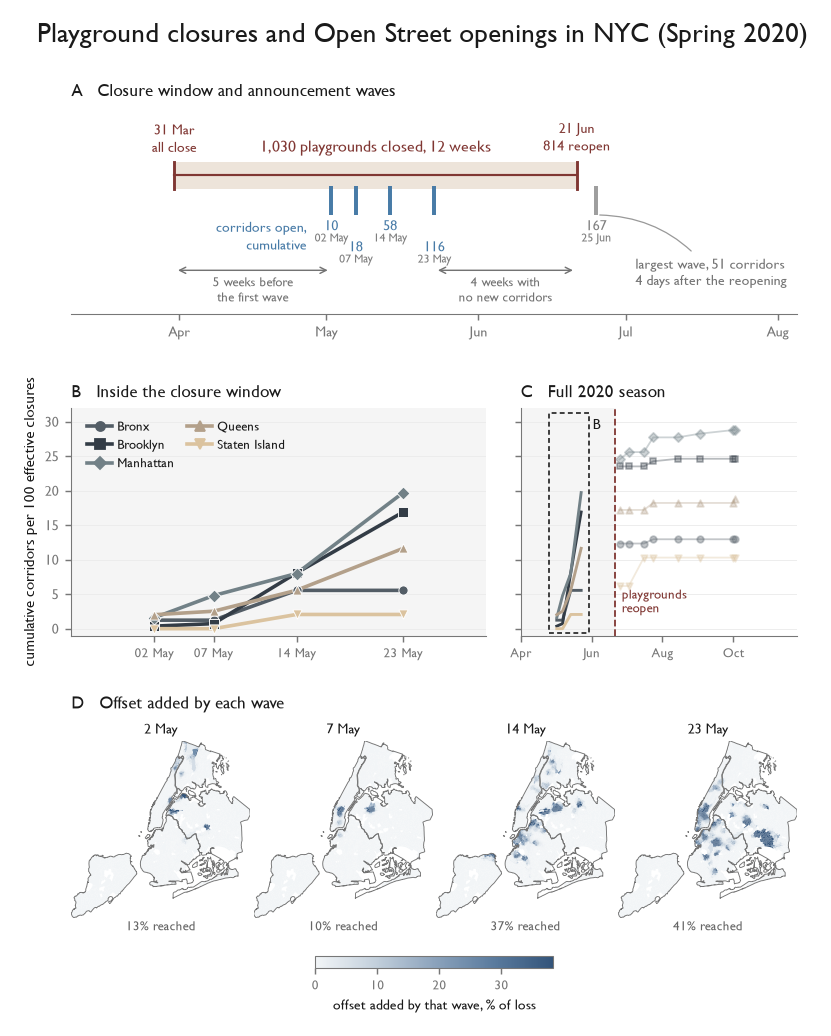

In [15]:
EFF = pd.Series(meta["effective_closures_by_borough"])
CLOSE_START, REOPEN = pd.Timestamp("2020-03-31"), pd.Timestamp("2020-06-21")
WAVES = pd.to_datetime(meta["waves"])
IN_WINDOW, LATE = WAVES[-1], pd.Timestamp("2020-06-25")

# each corridor counts once, on the date its first block opened
first_open = corr.sort_values("open_dt").drop_duplicates("corr_id")

ct = pd.crosstab(first_open["open_dt"], first_open["Borough"]).reindex(columns=BORO, fill_value=0)
cum = (100 * ct / EFF).cumsum()
inw = cum.index <= IN_WINDOW

by_date = first_open.groupby("open_dt").size().sort_index().cumsum()
counts = [int(by_date.loc[:w].iloc[-1]) for w in WAVES]
late_n = int(by_date.loc[:LATE].iloc[-1])
late_wave = int(by_date.loc[:LATE].iloc[-1] - by_date.loc[:LATE - pd.Timedelta(days=1)].iloc[-1])
wk_closed = (REOPEN - CLOSE_START).days / 7
wk_to_first = (WAVES[0] - CLOSE_START).days / 7
wk_gap = (REOPEN - WAVES[-1]).days / 7

print(f"corridors open at each wave: {counts}  |  by 25 June: {late_n} ({late_wave} that day)")

cols = [f"os_{k}" for k in WKEY]
LABS = ["2 May", "7 May", "14 May", "23 May"]
bnds = nyc.total_bounds

frames, prev = [], np.zeros(len(bg_geo))
for c in cols:
    cu = (100 * (bg_geo[c] - bg_geo["closure"]) / bg_geo["loss"]).values
    frames.append(cu - prev)
    prev = cu
vmax = float(np.nanpercentile(np.concatenate(frames), 97))

fig = plt.figure(figsize=(W2, 8.6))
gs = GridSpec(3, 2, height_ratios=[1.0, 1.10, 1.15], width_ratios=[1.5, 1],
              hspace=0.42, wspace=0.10)

a0 = fig.add_subplot(gs[0, :])
a0.fill_between([CLOSE_START, REOPEN], -0.10, 0.10, color="#EDE4DA", lw=0, zorder=1)
a0.plot([CLOSE_START, REOPEN], [0, 0], color=LOSS, lw=1.2, zorder=2)
for e in (CLOSE_START, REOPEN):
    a0.plot([e, e], [-0.10, 0.10], color=LOSS, lw=1.6, zorder=3)

a0.annotate(f"{meta['playgrounds_nominal']:,} playgrounds closed, {wk_closed:.0f} weeks",
            (CLOSE_START + (REOPEN - CLOSE_START) / 2, 0.15),
            ha="center", va="bottom", fontsize=9, color=LOSS)
a0.annotate("31 Mar\nall close", (CLOSE_START, 0.15), ha="center", va="bottom",
            fontsize=7.5, color=LOSS, linespacing=1.4)
a0.annotate("21 Jun\n814 reopen", (REOPEN, 0.15), ha="center", va="bottom",
            fontsize=7.5, color=LOSS, linespacing=1.4)

for k, (wdate, n) in enumerate(zip(WAVES, counts)):
    a0.vlines(wdate, -0.30, -0.08, color=OSC, lw=2.2, zorder=4)
    yy = -0.34 if k % 2 == 0 else -0.50
    a0.annotate(f"{n}", (wdate, yy), ha="center", va="top", fontsize=8, color=OSC)
    a0.annotate(wdate.strftime("%d %b"), (wdate, yy - 0.10), ha="center", va="top",
                fontsize=6.5, color="0.5")

a0.annotate("corridors open,\ncumulative", (WAVES[0] - pd.Timedelta(days=5), -0.34),
            ha="right", va="top", fontsize=7.5, color=OSC, linespacing=1.3)

a0.vlines(LATE, -0.30, -0.08, color="0.62", lw=2.2, zorder=4)
a0.annotate(f"{late_n}", (LATE, -0.34), ha="center", va="top", fontsize=8, color="0.5")
a0.annotate("25 Jun", (LATE, -0.44), ha="center", va="top", fontsize=6.5, color="0.5")


def bracket(x0, x1, y, txt, col="0.45"):
    a0.annotate("", (x0, y), (x1, y),
                arrowprops=dict(arrowstyle="<->", color=col, lw=0.8))
    a0.annotate(txt, (x0 + (x1 - x0) / 2, y - 0.03), ha="center", va="top",
                fontsize=7, color=col, linespacing=1.3)


bracket(CLOSE_START, WAVES[0], -0.72, f"{wk_to_first:.0f} weeks before\nthe first wave")
bracket(WAVES[-1], REOPEN, -0.72, f"{wk_gap:.0f} weeks with\nno new corridors")

a0.annotate(f"largest wave, {late_wave} corridors\n{(LATE - REOPEN).days} days after the reopening",
            (LATE, -0.30), (LATE + pd.Timedelta(days=8), -0.62),
            ha="left", va="top", fontsize=7.5, color="0.45", linespacing=1.3,
            arrowprops=dict(arrowstyle="-", color="0.6", lw=0.7,
                            connectionstyle="arc3,rad=0.25"))

a0.set_ylim(-1.05, 0.52)
a0.set_xlim(pd.Timestamp("2020-03-10"), pd.Timestamp("2020-08-05"))
a0.set_yticks([])
for s in ("left", "right", "top"):
    a0.spines[s].set_visible(False)
a0.xaxis.set_major_locator(mdates.MonthLocator())
a0.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
a0.grid(False)
a0.set_title("A   Closure window and announcement waves", loc="left", fontsize=9.5)

a1 = fig.add_subplot(gs[1, 0])
a1.axvspan(CLOSE_START, REOPEN, color="#F5F5F5", zorder=0)
for b in BORO:
    a1.plot(cum.index[inw], cum[b][inw], "-", color=BORO_C[b], lw=2.0, zorder=4)
    a1.scatter(cum.index[inw], cum[b][inw], color=BORO_C[b], marker=BORO_MK[b],
               s=26, edgecolor="white", lw=0.5, zorder=5)
a1.set_xlim(pd.Timestamp("2020-04-25"), pd.Timestamp("2020-05-30"))
a1.xaxis.set_major_locator(mdates.DayLocator(bymonthday=[2, 7, 14, 23]))
a1.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
a1.tick_params(axis="x", labelsize=7)
a1.set_ylabel("cumulative corridors per 100 effective closures")
a1.set_ylim(-1, 32)
a1.grid(axis="y")
a1.set_title("B   Inside the closure window", loc="left", fontsize=9.5)
a1.legend(handles=[Line2D([], [], color=BORO_C[b], marker=BORO_MK[b], ms=5,
                          lw=2.0, label=b) for b in BORO],
          frameon=False, fontsize=7, ncol=2, loc="upper left",
          bbox_to_anchor=(0.01, 0.99), columnspacing=1.0, handletextpad=0.4)

a2 = fig.add_subplot(gs[1, 1], sharey=a1)
a2.axvspan(CLOSE_START, REOPEN, color="#F5F5F5", zorder=0)
a2.axvline(REOPEN, color=LOSS, lw=1, ls="--", zorder=2)
for b in BORO:
    a2.plot(cum.index[inw], cum[b][inw], "-", color=BORO_C[b], lw=1.6, zorder=4)
    a2.plot(cum.index[~inw], cum[b][~inw], "-", color=BORO_C[b], lw=1.0, alpha=0.35, zorder=3)
    a2.scatter(cum.index[~inw], cum[b][~inw], color=BORO_C[b], marker=BORO_MK[b],
               s=13, alpha=0.35, zorder=4)
a2.text(REOPEN + pd.Timedelta(days=6), 1.5, "playgrounds\nreopen", fontsize=7,
        color=LOSS, va="bottom", linespacing=1.3)
a2.set_xlim(pd.Timestamp("2020-04-01"), pd.Timestamp("2020-11-25"))
a2.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
a2.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
a2.tick_params(axis="x", labelsize=7)
a2.grid(axis="y")
a2.tick_params(labelleft=False)

zx0, zx1 = a1.get_xlim()
zy0, zy1 = a1.get_ylim()
a2.add_patch(Rectangle((zx0, zy0 + 0.4), zx1 - zx0, (zy1 - zy0) - 1.2, fill=False,
                       edgecolor=INK, lw=0.9, ls=(0, (3, 2)), zorder=6))
a2.text(zx1 + 3, zy1 - 1.6, "B", ha="left", va="top", fontsize=8, color=INK)

a2.set_title("C   Full 2020 season", loc="left", fontsize=9.5)

gm = gs[2, :].subgridspec(1, 4, wspace=0.02)
maps = []
for j, (v, lab) in enumerate(zip(frames, LABS)):
    ax = fig.add_subplot(gm[j]); maps.append(ax)
    bg_geo.assign(v=np.clip(np.nan_to_num(v), 0, vmax)).plot(
        column="v", cmap=OSC_CMAP, vmin=0, vmax=vmax, ax=ax, lw=0, zorder=2)
    nyc.boundary.plot(ax=ax, color="0.45", lw=0.5, zorder=3)
    ax.set_xlim(bnds[0], bnds[2]); ax.set_ylim(bnds[1], bnds[3])
    ax.set_aspect("equal"); ax.axis("off")
    ax.set_title(lab, loc="center", fontsize=8, pad=4)
    reached = 100 * np.average(np.nan_to_num(v) > 0.5, weights=bg_geo["pop"])
    ax.text(0.5, -0.02, f"{reached:.0f}% reached", transform=ax.transAxes,
            ha="center", va="top", fontsize=7, color="0.4")

maps[0].text(0, 1.16, "D   Offset added by each wave", transform=maps[0].transAxes,
             ha="left", va="bottom", fontsize=9.5)

sm = plt.cm.ScalarMappable(cmap=OSC_CMAP, norm=plt.Normalize(0, vmax))
cb = fig.colorbar(sm, ax=maps, orientation="horizontal", fraction=0.05,
                  pad=0.16, shrink=0.35)
cb.set_label("offset added by that wave, % of loss", fontsize=7.5)
cb.ax.tick_params(labelsize=7)

fig.suptitle("Playground closures and Open Street openings in NYC (Spring 2020)",
             y=0.955, fontsize=15)

save(fig, "fig4_design_waves")

## Figure 5. Where loss and offset landed

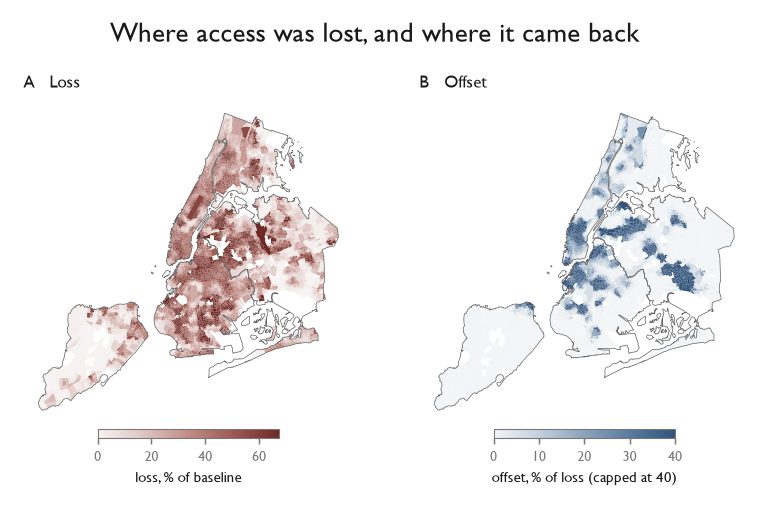

In [17]:
g = bg_geo.copy()
g["loss_pct"] = 100 * g["loss"] / g["baseline"]
g["offset_pct"] = (100 * g[f"offset_{WKEY[-1]}"] / g["loss"]).clip(0, 40)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(W2, 4.2))
g.plot(column="loss_pct", cmap=LOSS_CMAP, ax=a1, lw=0,
       vmin=0, vmax=g["loss_pct"].quantile(0.95), legend=True,
       legend_kwds={"shrink": 0.55, "orientation": "horizontal", "pad": 0.01,
                    "label": "loss, % of baseline"})
g.plot(column="offset_pct", cmap=OSC_CMAP, ax=a2, lw=0, legend=True,
       legend_kwds={"shrink": 0.55, "orientation": "horizontal", "pad": 0.01,
                    "label": "offset, % of loss (capped at 40)"})

for a, lab in zip((a1, a2), ("A   Loss", "B   Offset")):
    nyc.boundary.plot(ax=a, color="0.4", lw=0.4)
    a.set_aspect("equal")
    a.axis("off")
    a.set_title(lab, loc="left", fontsize=9.5)

fig.suptitle("Where access was lost, and where it came back", y=0.97, fontsize=15)

save(fig, "fig5_loss_offset")

## Figure 6. Population exposure

check: 8,798,936 vs 8,798,936
  no park or playground within 800 m            307,959    3.5%
  park but no playground accessible              48,877    0.6%
  park access, no loss where they live           54,631    0.6%
  lost access, recovered nothing              2,389,974   27.2%
  lost access, recovered some                 5,997,496   68.2%


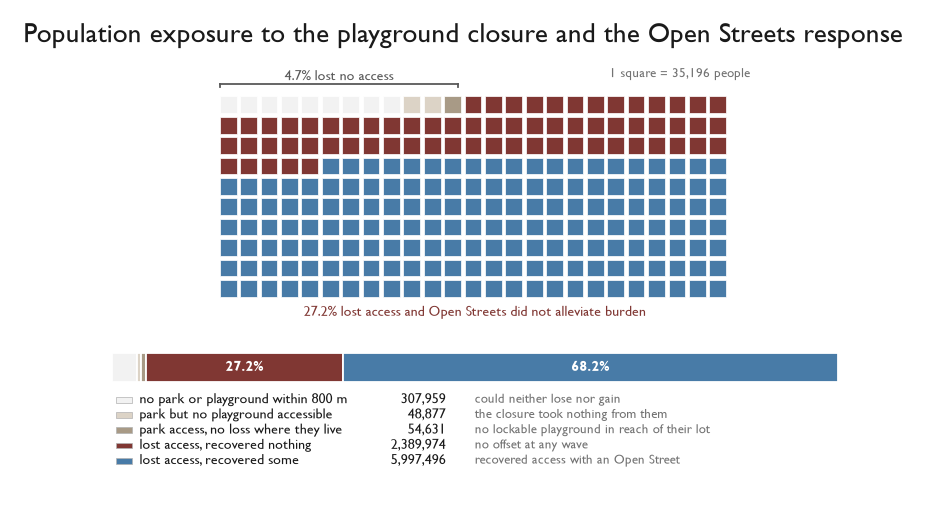

In [19]:
TOTAL = meta["population"]
NO_PARK = meta["no_access_pop"]
LOST = meta["lost_access_pop"]
ZERO = meta["no_recovery_pop"]
BETTER = meta["better_off_pop"]

NO_PG = emeta["no_playground_pop"]
NO_LOSS = TOTAL - NO_PARK - NO_PG - LOST
SOME = LOST - ZERO

C = ["#F2F2F2", "#DCD3C6", "#A89A86", LOSS, OSC]
TXTC = ["#111111", "#111111", "white", "white", "white"]
NAMES = ["no park or playground within 800 m", "park but no playground accessible",
         "park access, no loss where they live", "lost access, recovered nothing",
         "lost access, recovered some"]
NOTES = ["could neither lose nor gain", "the closure took nothing from them",
         "no lockable playground in reach of their lot",
         "no offset at any wave",
         "recovered access with an Open Street"]
VALS = [NO_PARK, NO_PG, NO_LOSS, ZERO, SOME]

NCOL, NROW = 25, 10
cells = NCOL * NROW
alloc, run = [], 0.0
for v, c in zip(VALS, C):
    k = v / TOTAL * cells
    alloc.append((c, run, run + k)); run += k

fig = plt.figure(figsize=(W2, W2 * 0.58))
gs = GridSpec(2, 1, height_ratios=[1.35, 0.76], hspace=0.10)

ax = fig.add_subplot(gs[0])
for i in range(cells):
    r, ci = divmod(i, NCOL)
    col = "#EEEEEE"
    for c, lo, hi in alloc:
        if lo <= i < hi:
            col = c; break
    ax.add_patch(Rectangle((ci, NROW - 1 - r), 0.82, 0.82, facecolor=col,
                           edgecolor="white", lw=0.4))

untouched = (NO_PARK + NO_PG + NO_LOSS) / TOTAL * cells
ax.plot([0, untouched], [NROW + 0.42] * 2, color="0.35", lw=1.0)
for xx in (0, untouched):
    ax.plot([xx, xx], [NROW + 0.26, NROW + 0.42], color="0.35", lw=1.0)
ax.text(untouched / 2, NROW + 0.62,
        f"{100*(NO_PARK+NO_PG+NO_LOSS)/TOTAL:.1f}% lost no access",
        ha="center", fontsize=8, color="0.35")
ax.text(NCOL / 2, -0.45,
        f"{100*ZERO/TOTAL:.1f}% lost access and Open Streets did not alleviate burden",
        ha="center", va="top", fontsize=8, color=LOSS)
ax.text(NCOL + 1, NROW + 0.62, f"1 square = {TOTAL/cells:,.0f} people",
        ha="right", va="bottom", fontsize=7, color="0.45")
ax.set_xlim(-1, NCOL + 1); ax.set_ylim(-1.35, NROW + 1.15)
ax.set_aspect("equal"); ax.axis("off")

axb = fig.add_subplot(gs[1])
left = 0.0
for v, c, tc in zip(VALS, C, TXTC):
    wid = 100 * v / TOTAL
    axb.barh(0, wid, left=left, height=0.5, color=c, edgecolor="white", lw=1.0)
    if wid > 6:
        axb.text(left + wid / 2, 0, f"{wid:.1f}%", ha="center", va="center",
                 fontsize=8, color=tc, fontweight="bold")
    left += wid

for i, (n, v, c, note) in enumerate(zip(NAMES, VALS, C, NOTES)):
    yy = -0.55 - i * 0.26
    axb.add_patch(Rectangle((0.6, yy - 0.050), 2.2, 0.10, facecolor=c,
                            edgecolor="0.7", lw=0.4, clip_on=False))
    axb.text(3.8, yy, n, va="center", fontsize=7.6, clip_on=False)
    axb.text(46, yy, f"{v:,.0f}", va="center", ha="right", fontsize=7.6, clip_on=False)
    axb.text(50, yy, note, va="center", fontsize=7.0, color="0.45", clip_on=False)
axb.set_xlim(0, 100); axb.set_ylim(-2.05, 0.40); axb.axis("off")

fig.suptitle("Population exposure to the playground closure and the Open Streets response",
             y=0.965, fontsize=15)

save(fig, "fig6_exposure")
print(f"check: {sum(VALS):,.0f} vs {TOTAL:,.0f}")
for n, v in zip(NAMES, VALS):
    print(f"  {n:40} {v:>12,.0f}  {100 * v / TOTAL:5.1f}%")

## Figure 7. Loss and offset by quintile

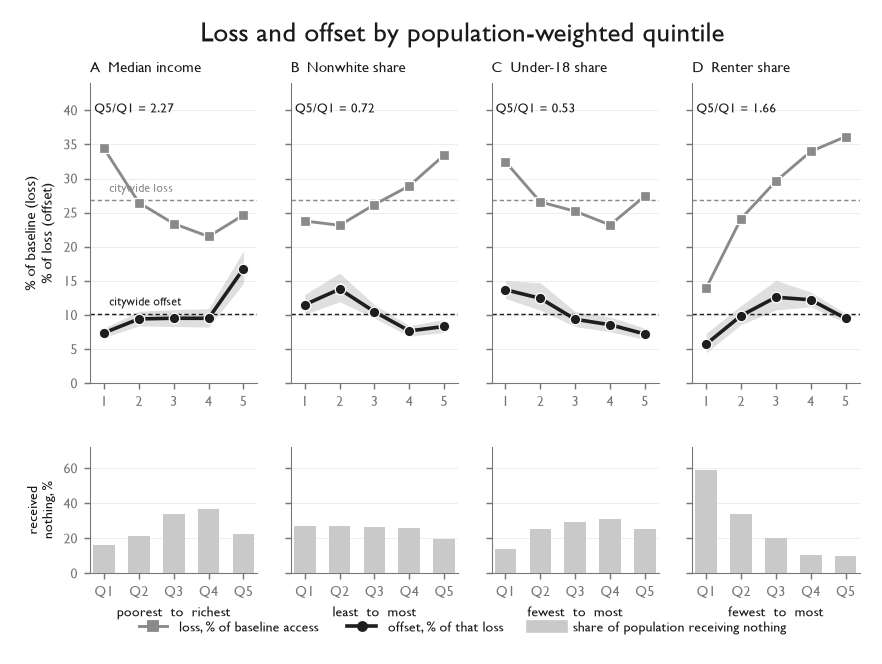

In [21]:
VARS = [("med_income", "Median income", "poorest", "richest"),
        ("pct_nonwhite", "Nonwhite share", "least", "most"),
        ("pct_under18", "Under-18 share", "fewest", "most"),
        ("pct_renter", "Renter share", "fewest", "most")]
LOSSC, OFFC = "#8A8A8A", "#1E1E1E"
q = np.arange(1, 6)

fig = plt.figure(figsize=(W2 * 1.06, W2 * 0.68))
gs = GridSpec(2, 4, height_ratios=[1, 0.42], hspace=0.30, wspace=0.20)

for j, (key, label, lo, hi) in enumerate(VARS):
    gq = grads[grads["variable"] == key].sort_values("q")

    ax = fig.add_subplot(gs[0, j])
    ax.axhline(CITY_LOSS, color=LOSSC, lw=0.8, ls=(0, (3, 2)), zorder=1)
    ax.axhline(CITY_OFF, color=OFFC, lw=0.8, ls=(0, (3, 2)), zorder=1)

    ax.plot(q, gq["pct_loss"], "-", color=LOSSC, lw=1.6, zorder=3)
    ax.scatter(q, gq["pct_loss"], marker="s", s=30, color=LOSSC,
               edgecolor="white", lw=0.7, zorder=4)

    ax.fill_between(q, gq["offset_lo"], gq["offset_hi"], color=OFFC, alpha=0.14, lw=0, zorder=2)
    ax.plot(q, gq["offset_pct"], "-", color=OFFC, lw=2.0, zorder=5)
    ax.scatter(q, gq["offset_pct"], marker="o", s=34, color=OFFC,
               edgecolor="white", lw=0.7, zorder=6)

    ratio = gq["offset_pct"].iloc[-1] / gq["offset_pct"].iloc[0]
    ax.text(0.72, 41, f"Q5/Q1 = {ratio:.2f}", fontsize=7, color=OFFC, va="top")

    ax.set_ylim(0, 44); ax.set_xlim(0.6, 5.4)
    ax.set_xticks(q, [str(i) for i in q])
    ax.set_title(f"{'ABCD'[j]}  {label}", loc="left", fontsize=8.5)
    ax.grid(axis="y")
    if j == 0:
        ax.set_ylabel("% of baseline (loss)\n% of loss (offset)")
        ax.text(1.15, CITY_LOSS + 1.2, "citywide loss", fontsize=6.8, color=LOSSC)
        ax.text(1.15, CITY_OFF + 1.2, "citywide offset", fontsize=6.8, color=OFFC)
    else:
        ax.tick_params(labelleft=False)

    axz = fig.add_subplot(gs[1, j])
    axz.bar(q, gq["zero_offset_pct"], width=0.62, color="#C9C9C9", zorder=3)
    axz.set_ylim(0, 72); axz.set_xlim(0.6, 5.4)
    axz.set_xticks(q, [f"Q{i}" for i in q], fontsize=7.5)
    axz.set_xlabel(f"{lo}  to  {hi}", fontsize=7.5)
    axz.grid(axis="y")
    if j == 0:
        axz.set_ylabel("received\nnothing, %", fontsize=7.5)
    else:
        axz.tick_params(labelleft=False)

fig.legend(handles=[
    Line2D([], [], color=LOSSC, marker="s", ms=5, lw=1.6, label="loss, % of baseline access"),
    Line2D([], [], color=OFFC, marker="o", ms=5, lw=2.0, label="offset, % of that loss"),
    Line2D([], [], color="#C9C9C9", lw=7, label="share of population receiving nothing")],
    frameon=False, fontsize=8, ncol=3, loc="upper center", bbox_to_anchor=(0.5, 0.055))

fig.suptitle("Loss and offset by population-weighted quintile",
             y=0.975, fontsize=15)

save(fig, "fig7_equity_gradient")

## Figure 8. Predictors of offset

n = 5,632  |  R2 0.149 to 0.162


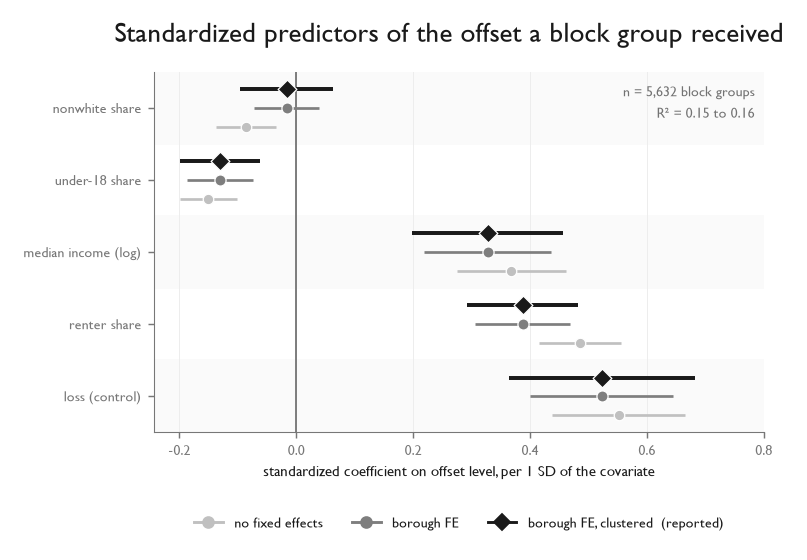

In [23]:
mpl.rcParams["axes.unicode_minus"] = False

std = pd.read_csv(PROCESSED / "equity_regressions_std.csv")

LABELS = {"z_pct_nonwhite": "nonwhite share", "z_pct_under18": "under-18 share",
          "z_log_income": "median income (log)", "z_pct_renter": "renter share",
          "z_loss": "loss (control)"}
TERMS = list(LABELS)
SPECS = ["no fixed effects", "borough FE", "borough FE, clustered"]
COLS = ["#C0C0C0", "#7E7E7E", INK]
MARKS = ["o", "o", "D"]
SIZES = [34, 38, 54]
OFFS = [0.26, 0.00, -0.26]

fig, ax = plt.subplots(figsize=(W2 * 0.84, 3.6))
y = np.arange(len(TERMS))
for i in range(len(TERMS)):
    if i % 2 == 0:
        ax.axhspan(i - 0.5, i + 0.5, color="#FAFAFA", zorder=0)
ax.axvline(0, color="0.45", lw=1, zorder=1)

for lab, c, mk, sz, off in zip(SPECS, COLS, MARKS, SIZES, OFFS):
    m = std[std["model"] == lab].set_index("term").loc[TERMS]
    yy = y + off
    ax.hlines(yy, m["coef"] - 1.96 * m["se"], m["coef"] + 1.96 * m["se"],
              color=c, lw=2.2 if c == INK else 1.5, zorder=2)
    ax.scatter(m["coef"], yy, marker=mk, s=sz, color=c, edgecolor="white",
               lw=0.7, zorder=3)

ax.set_yticks(y, [LABELS[t] for t in TERMS])
ax.set_ylim(len(TERMS) - 0.5, -0.5)
ax.set_xticks([-0.2, 0.0, 0.2, 0.4, 0.6, 0.8],
              ["-0.2", "0.0", "0.2", "0.4", "0.6", "0.8"])
ax.set_xlabel("standardized coefficient on offset level, per 1 SD of the covariate")
ax.grid(axis="x")

r2 = std.groupby("model")["r2"].first()
n = int(std.loc[std["model"] == SPECS[0], "n"].iloc[0])
ax.text(0.985, 0.97,
        f"n = {n:,} block groups\nR² = {r2['no fixed effects']:.2f} to {r2['borough FE']:.2f}",
        transform=ax.transAxes, ha="right", va="top", fontsize=8, color="0.45",
        linespacing=1.5)

ax.legend(handles=[Line2D([], [], color=c, marker=mk, ls="-", ms=6, lw=1.6,
                          label=lab + ("  (reported)" if lab == SPECS[-1] else ""))
                   for lab, c, mk in zip(SPECS, COLS, MARKS)],
          frameon=False, fontsize=8, ncol=3, loc="upper center",
          bbox_to_anchor=(0.5, -0.20))

fig.suptitle("Standardized predictors of the offset a block group received",
             y=0.985, fontsize=15)

save(fig, "fig8_forest")
print(f"n = {n:,}  |  R2 {r2['no fixed effects']:.3f} to {r2['borough FE']:.3f}")

## Figure 9. Sensitivity to specification

                              city    gap  ratio
spec                                            
width minus 4.8 m             7.13   7.79   6.76
standard denominator          8.00   7.43   3.04
width minus 2.4 m             8.79   9.32   5.52
euclidean impedance           9.67   9.95   5.10
parks under 1000 m2 dropped   9.82  10.41   5.16
parks under 500 m2 dropped    9.98  10.54   5.14
area, network, competition   10.19  10.69   5.11
gaussian decay               10.40  11.57   5.57
count-weighted               17.89  19.05   5.14
segments, not corridors      18.91  18.91   5.52


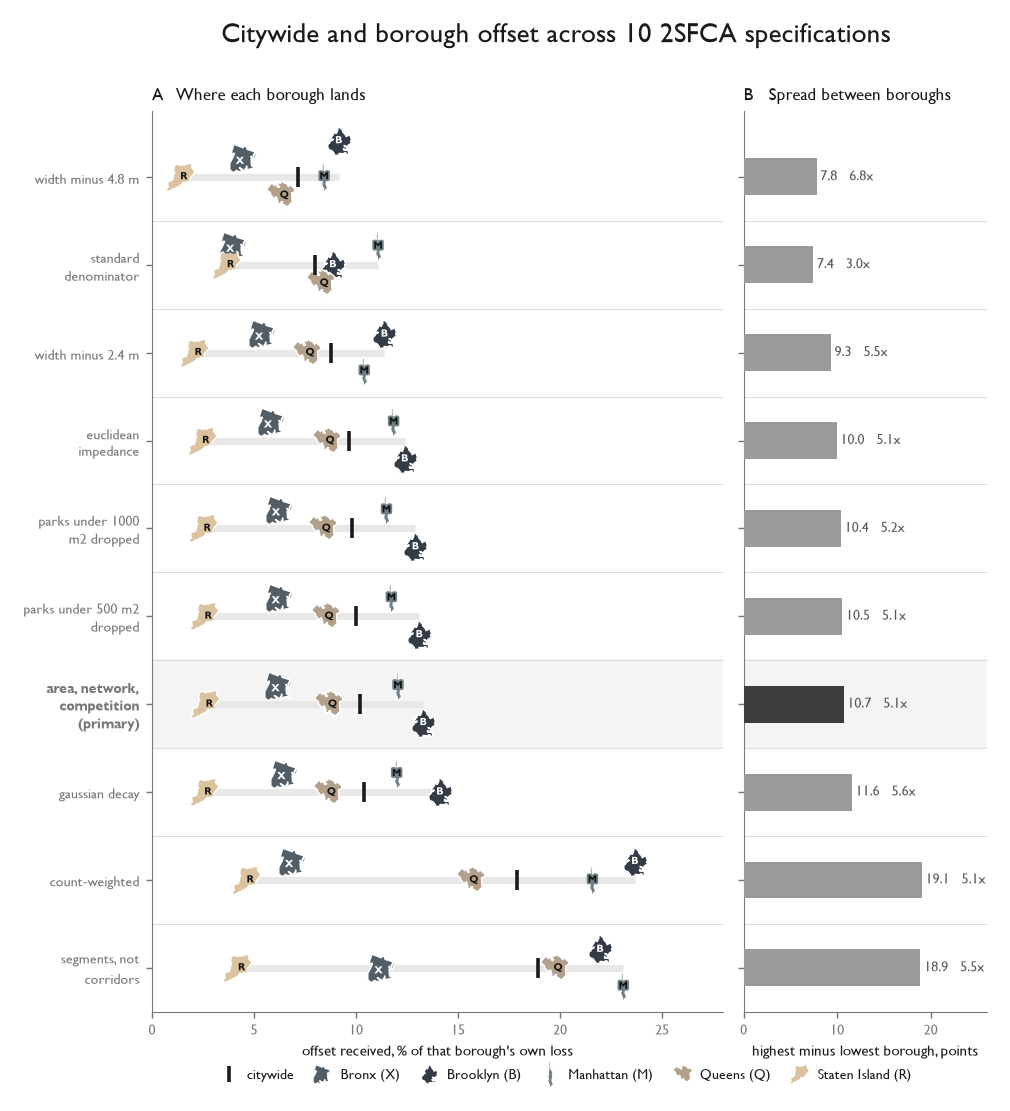

In [25]:
sens = pd.read_csv(PROCESSED / "sensitivity.csv")

BUP = dict(zip(BORO, [False, False, True, False, False]))


def boro_path(g, upright=False, simp=800):
    p = max(g.geoms, key=lambda q: q.area) if g.geom_type == "MultiPolygon" else g
    xy = np.array(p.simplify(simp).exterior.coords, dtype=float)
    xy -= xy.mean(0)
    if upright:
        vt = np.linalg.svd(xy, full_matrices=False)[2]
        a = np.arctan2(vt[0, 1], vt[0, 0]) - np.pi / 2
        c, s_ = np.cos(-a), np.sin(-a)
        xy = xy @ np.array([[c, s_], [-s_, c]])
    xy -= (xy.min(0) + xy.max(0)) / 2
    xy /= np.abs(xy).max() * 2
    return Path(xy, [Path.MOVETO] + [Path.LINETO] * (len(xy) - 2) + [Path.CLOSEPOLY])


CODE = dict(zip(BORO, ["X", "B", "M", "Q", "R"]))
SHAPE = {b: boro_path(nyc.loc[b, "geometry"], upright=BUP[b]) for b in BORO}
BFILL = BORO_C
BTXT = BORO_TXT
BSIZE = {b: 250 for b in BORO}
BDX = dict(zip(BORO, [-0.15, 0.0, 0.0, 0.20, 0.20]))
BDY = dict(zip(BORO, [0.07, 0.0, 0.0, 0.0, 0.0]))
BLEG = dict(zip(BORO, [11, 11, 15, 11, 11]))
PRIMARY = "area, network, competition"
WRAP = 18

s = sens.copy()
s["gap"] = s[BORO].max(axis=1) - s[BORO].min(axis=1)
s["ratio"] = s[BORO].max(axis=1) / s[BORO].min(axis=1)
order = s.sort_values("city").reset_index(drop=True)

ROW = 2.0
MIN_GAP = 5.2
LANES = np.array([0.0, -0.21, 0.21, -0.41, 0.41]) * ROW

fig = plt.figure(figsize=(W2 * 1.15, 9.0))
gs = GridSpec(1, 2, width_ratios=[2.35, 1], wspace=0.05)
ax = fig.add_subplot(gs[0])
y = np.arange(len(order)) * ROW

for i, r in order.iterrows():
    yc = i * ROW
    vals = np.array([r[b] for b in BORO])
    if r["spec"] == PRIMARY:
        ax.axhspan(yc - ROW / 2, yc + ROW / 2, color="#F4F4F4", zorder=0)
    if i:
        ax.axhline(yc - ROW / 2, color="#DCDCDC", lw=0.6, zorder=1)
    ax.hlines(yc, vals.min(), vals.max(), color="#E8E8E8", lw=4, zorder=2)

    occ = {li: -1e9 for li in range(len(LANES))}
    lane = {}
    for k in np.argsort(vals):
        for li in range(len(LANES)):
            if vals[k] - occ[li] >= MIN_GAP:
                lane[k], occ[li] = li, vals[k]
                break
        else:
            lane[k] = len(LANES) - 1

    for k, b in enumerate(BORO):
        yy = yc + LANES[lane[k]]
        ax.scatter(r[b], yy, marker=SHAPE[b], s=BSIZE[b], facecolor=BFILL[b],
                   edgecolor="white", lw=0.8, zorder=4)
        ax.text(r[b] + BDX[b], yy + BDY[b], CODE[b], ha="center", va="center",
                fontsize=5.8, color=BTXT[b], fontweight="bold", zorder=5,
                path_effects=[pe.withStroke(linewidth=2.1, foreground=BFILL[b])])
    ax.scatter(r["city"], yc, marker="|", s=130, color=INK, lw=2.0, zorder=6)

lbl = [textwrap.fill(r["spec"], WRAP) + ("\n(primary)" if r["spec"] == PRIMARY else "")
       for _, r in order.iterrows()]
ax.set_yticks(y, lbl, fontsize=8, linespacing=1.35)
for t, (_, r) in zip(ax.get_yticklabels(), order.iterrows()):
    if r["spec"] == PRIMARY:
        t.set_fontweight("bold")
ax.set_ylim((len(order) - 1) * ROW + ROW / 2, -ROW / 2 - 0.5)
ax.set_xlim(0, 28)
ax.set_xlabel("offset received, % of that borough's own loss")
ax.grid(False)
ax.set_title("A   Where each borough lands", loc="left")

axg = fig.add_subplot(gs[1], sharey=ax)
for i, r in order.iterrows():
    yc = i * ROW
    if r["spec"] == PRIMARY:
        axg.axhspan(yc - ROW / 2, yc + ROW / 2, color="#F4F4F4", zorder=0)
    if i:
        axg.axhline(yc - ROW / 2, color="#DCDCDC", lw=0.6, zorder=1)
    axg.barh(yc, r["gap"], height=0.42 * ROW, zorder=3,
             color="#3C3C3C" if r["spec"] == PRIMARY else "#9A9A9A")
    axg.text(r["gap"] + 0.4, yc, f"{r['gap']:.1f}   {r['ratio']:.1f}x",
             va="center", fontsize=7.5, color="0.35")
axg.axvline(0, color="0.5", lw=1)
axg.set_xlim(0, 26)
axg.set_xlabel("highest minus lowest borough, points")
axg.grid(False); axg.tick_params(labelleft=False)
axg.set_title("B   Spread between boroughs", loc="left")

handles = [Line2D([], [], ls="", marker="|", color=INK, ms=9, mew=2.0, label="citywide")]
handles += [Line2D([], [], ls="", marker=SHAPE[b], markerfacecolor=BFILL[b],
                   markeredgecolor="white", markeredgewidth=0.8, ms=BLEG[b],
                   color="none", label=f"{b} ({CODE[b]})") for b in BORO]
ax.legend(handles=handles, frameon=False, fontsize=7.5, ncol=6,
          loc="upper center", bbox_to_anchor=(0.72, -0.05),
          columnspacing=1.1, handletextpad=0.35)

fig.suptitle(f"Citywide and borough offset across {len(order)} 2SFCA specifications",
             y=0.955, fontsize=15)

save(fig, "fig9_sensitivity")
print(order.set_index("spec")[["city", "gap", "ratio"]].round(2).to_string())

## Tables

We tabulate each step from the archived Open Streets capture to the supply points that enter the model, and from the 2020 census count to the analytic sample, so a reader can trace every exclusion to its source.

In [27]:
CENSUS_2020 = 8804190
surface_pop = pd.read_parquet(PROCESSED / "ceds_pop_nyc_2020.parquet", columns=["pop_ceds"])["pop_ceds"].sum()
with_park = meta["population"] - meta["no_access_pop"]

os_steps = pd.DataFrame([
    ("Records in archived capture", 1607, ""),
    ("Full-block closures", 1271, "excludes bike lanes and outdoor dining"),
    ("Unique segments", 879, "capture duplicates 31% of rows"),
    ("Outside park polygons", 817, "62 park roads already counted as park supply"),
    ("Contiguous corridors", meta["open_streets_corridors"], "multi-block streets merged"),
    ("Supply points", meta["open_streets_supply_points"], "corridors split where blocks opened in different waves"),
    (f"Corridors open by {WAVES[-1]:%d %b}", counts[-1], "in whole or in part"),
], columns=["step", "n", "note"])

pop_steps = pd.DataFrame([
    ("Population, 2020 Census", CENSUS_2020, ""),
    ("Allocated to tax lot pieces", surface_pop,
          f"{CENSUS_2020 - surface_pop:,.0f} unallocated: Rikers Island and two water-only block groups"),
    ("On demand points", meta["population"], "pieces below 0.5 persons dropped"),
    ("With park access at baseline", with_park,
     f"{100 * meta['no_access_pop'] / meta['population']:.1f}% had no park or playground within 800 m"),
    ("With a playground in reach", emeta["pop_analyzed"],
     f"{100 * emeta['no_playground_pop'] / meta['population']:.1f}% had park access but no playground"),
], columns=["step", "n", "note"])

for t, lab in [(os_steps, "Open Streets"), (pop_steps, "Analytic sample")]:
    t = t.copy()
    t["n"] = t["n"].map("{:,.0f}".format)
    print(f"\n{lab}\n{t.to_string(index=False)}")

os_steps.to_csv(PROCESSED / "table_pipeline_openstreets.csv", index=False)
pop_steps.to_csv(PROCESSED / "table_pipeline_sample.csv", index=False)


Open Streets
                       step     n                                                   note
Records in archived capture 1,607                                                       
        Full-block closures 1,271                 excludes bike lanes and outdoor dining
            Unique segments   879                         capture duplicates 31% of rows
      Outside park polygons   817           62 park roads already counted as park supply
       Contiguous corridors   184                             multi-block streets merged
              Supply points   191 corridors split where blocks opened in different waves
   Corridors open by 23 May   116                                    in whole or in part

Analytic sample
                        step         n                                                             note
     Population, 2020 Census 8,804,190                                                                 
 Allocated to tax lot pieces 8,800,353 3,837 unal